## 1. Setup & Overview

# Home Credit Default Risk - EDA

> **Dataset:** `application_train.csv` from the [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) competition.
>
> **Goal:** Explore the data to understand class imbalance, missing values, and which features correlate with `TARGET` (1 = client defaulted on their loan, 0 = paid it back), ahead of building a predictive model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('application_train.csv')
df.shape

(307511, 122)

In [2]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [4]:
df.dtypes

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

## 2. Target Imbalance Check

#### Check imbalance
> See how skewed TARGET is between defaulters and non-defaulters

In [5]:
df['TARGET'].value_counts(normalize=True) # 91.9% Paid back their loan, 8.1% didnt

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Text(0, 0.5, 'Count')

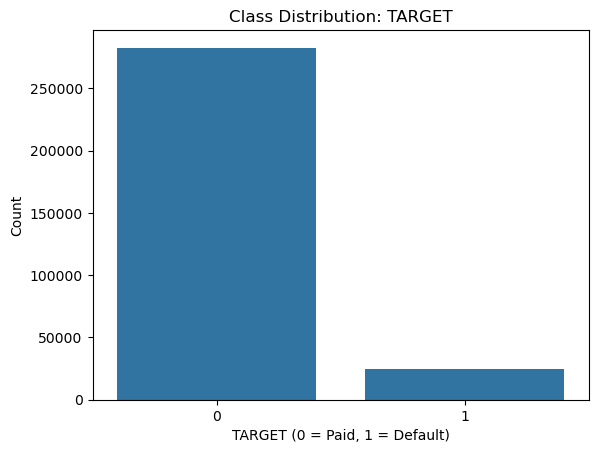

In [6]:
sns.countplot(x='TARGET', data=df)
plt.title('Class Distribution: TARGET')
plt.xlabel('TARGET (0 = Paid, 1 = Default)')
plt.ylabel('Count')

#### Imbalance

> With almost 92% of people who paid back their loan, 8% did not which is a huge imbalance. 
>
> This imbalance could hurt the model **During Training** as it will see high **non-defaulters**, so it will learn to just predict 0 every time.
> 
> **During Testing** if we just go off accuracy, 92% would sound great but the model is useless as it just ignored the **Defaulters**
>
> To handle this imbalance we will go off metrics such as
- Recall - High recall means we catch more defaulters but we'll also flag more false positives.
- ROC-AUC (Receiver Operating Characteristic - Area Under Curve) - Plots the tradeoff at every threshold. A score of 0.5 is random guessing, 0.8+ is good. More honest than accuracy on imbalanced data.
>
> **Business Context:** - A bank would rather flag someone who would have paid then miss someone who's going to default


## 3. Missing Value Audit

#### Find missing values
> Identify how much data is missing per column, to decide which columns are worth keeping vs. dropping before imputation

In [7]:
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64


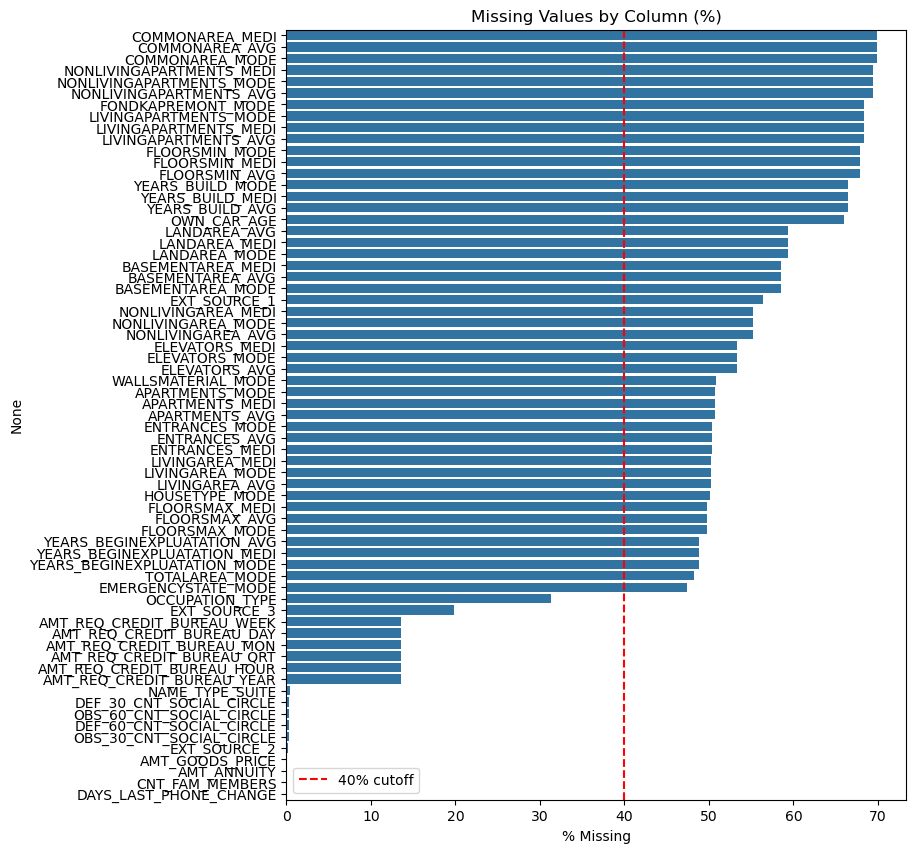

In [8]:
plt.figure(figsize=(8, 10))
sns.barplot(x=missing.values, y=missing.index)
plt.axvline(40, color='red', linestyle='--', label='40% cutoff')
plt.title('Missing Values by Column (%)')
plt.xlabel('% Missing')
plt.legend()
plt.show()

In [9]:
drop_cols = missing[missing > 40].index.tolist()
print(f"Columns to drop: {len(drop_cols)}")
print(drop_cols)

keep_cols = [c for c in df.columns if c not in drop_cols]
print(f"Columns kept: {len(keep_cols)}")
print(keep_cols)


Columns to drop: 49
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'EXT_SOURCE_1', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'WALLSMATERIAL_MODE', 'APARTMENTS_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'ENTRANCES_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'LIVINGAREA_AVG', 'HOUSETYPE_MODE', 'FLOORSMAX_MEDI', 'FLOORSMAX_AVG', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'TOTALAREA_MODE', 

#### Missing data
> Columns with more than 40% missing values (`drop_cols`) are strong *candidates* to drop, since imputing that much data would likely introduce more noise than signal — but that needs to be checked against each column's relationship with TARGET before actually dropping anything.
>
> 67 out of 122 columns had missing data. 49 of those have more than 40% missing (`drop_cols`); the remaining 73 columns (`keep_cols`) have little enough missing data to keep as-is for now.
>
> **No columns have been dropped from `df` yet.** Before finalizing `drop_cols`, I checked each candidate column's correlation with TARGET below — a column with real predictive signal might be worth keeping (e.g. via a dedicated imputation strategy) even with high missingness.

## 4. Categorical Variable Exploration

#### Check non-numerical values relationship with TARGET
> Before checking numeric correlation with TARGET, I'll first check how TARGET's default rate varies across non-numeric categories using groupby, since categorical columns aren't picked up by .corr().

In [10]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"--- {col} ---")
    summary = df.groupby(col)['TARGET'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    print(summary)
    print()


--- NAME_CONTRACT_TYPE ---
                        mean   count
NAME_CONTRACT_TYPE                  
Cash loans          0.083459  278232
Revolving loans     0.054783   29279

--- CODE_GENDER ---
                 mean   count
CODE_GENDER                  
M            0.101419  105059
F            0.069993  202448
XNA          0.000000       4

--- FLAG_OWN_CAR ---
                  mean   count
FLAG_OWN_CAR                  
N             0.085002  202924
Y             0.072437  104587

--- FLAG_OWN_REALTY ---
                     mean   count
FLAG_OWN_REALTY                  
N                0.083249   94199
Y                0.079616  213312

--- NAME_TYPE_SUITE ---
                     mean   count
NAME_TYPE_SUITE                  
Other_B          0.098305    1770
Other_A          0.087760     866
Group of people  0.084871     271
Unaccompanied    0.081830  248526
Spouse, partner  0.078716   11370
Family           0.074946   40149
Children         0.073768    3267

--- NAME_INCOME

                            mean  count
ORGANIZATION_TYPE                      
Transport: type 3       0.157540   1187
Industry: type 13       0.134328     67
Industry: type 8        0.125000     24
Restaurant              0.117062   1811
Construction            0.116798   6721
Cleaning                0.111538    260
Industry: type 1        0.110683   1039
Industry: type 3        0.106162   3278
Realtor                 0.106061    396
Agriculture             0.104727   2454
Trade: type 3           0.103379   3492
Self-employed           0.101739  38412
Industry: type 4        0.101482    877
Security                0.099784   3247
Trade: type 7           0.094496   7831
Business Entity Type 3  0.092996  67992
Transport: type 4       0.092812   5398
Mobile                  0.091483    317
Trade: type 1           0.089080    348
Industry: type 11       0.086538   2704
Business Entity Type 2  0.085284  10553
Postal                  0.084376   2157
Advertising             0.081585    429


                      mean   count
HOUSETYPE_MODE                    
specific housing  0.101401    1499
terraced house    0.084983    1212
block of flats    0.069434  150503

--- WALLSMATERIAL_MODE ---
                        mean  count
WALLSMATERIAL_MODE                 
Wooden              0.096979   5362
Others              0.083077   1625
Mixed               0.075348   2296
Stone, brick        0.074057  64815
Block               0.070247   9253
Panel               0.063477  66040
Monolithic          0.047218   1779

--- EMERGENCYSTATE_MODE ---
                         mean   count
EMERGENCYSTATE_MODE                  
Yes                  0.095790    2328
No                   0.069649  159428



In [11]:
df['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [12]:
df['ORGANIZATION_TYPE'].value_counts()

ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Industry: type 3           3278
Security                   3247
Housing                    2958
Industry: type 11          2704
Military                   2634
Bank                       2507
Agriculture                2454
Police                     2341
Transport: type 2          2204
Postal                     2157
Security Ministries        1974
Trade: type 2              1900
Restaurant                 1811
Services                   1575
University                 1327
Industry: type 7      

In [13]:
df[df['ORGANIZATION_TYPE'] == 'XNA']['NAME_INCOME_TYPE'].value_counts() # find XNA between ORGANIZATION_TYPE and how they get their income

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

#### "Weird Values"
> Only 4 **XNA** in **CODE_GENDER**, we'll ignore since this wont affect the model
>
> With 55,374 **XNA**'s in **ORGANIZATION_TYPE** I found out that 55,352 are **Pensioner** and 22 are **Unemployed**
>
> This confirms XNA here isnt missing/broken data - its just expected, since Pensioners and the Unemployed don't have an organization to report. I'll keep it as its own valid category rather than imputing or dropping these rows

## 5. Per-Column Deep Dives

#### Investigating EXT_SOURCE_1


In [14]:
for col in drop_cols:
    if df[col].dtype in ['float64', 'int64']:
        non_null = df[[col, 'TARGET']].dropna()
        corr = non_null[col].corr(non_null['TARGET'])
        print(f"{col}: corr = {corr:.4f}, n = {len(non_null)}")
    else:
        print(f"{col}: (categorical — skipped, check separately via group-by mean)")

COMMONAREA_MEDI: corr = -0.0186, n = 92646
COMMONAREA_AVG: corr = -0.0185, n = 92646
COMMONAREA_MODE: corr = -0.0163, n = 92646
NONLIVINGAPARTMENTS_MEDI: corr = -0.0028, n = 93997
NONLIVINGAPARTMENTS_MODE: corr = -0.0016, n = 93997
NONLIVINGAPARTMENTS_AVG: corr = -0.0032, n = 93997
FONDKAPREMONT_MODE: (categorical — skipped, check separately via group-by mean)
LIVINGAPARTMENTS_MODE: corr = -0.0234, n = 97312
LIVINGAPARTMENTS_MEDI: corr = -0.0246, n = 97312
LIVINGAPARTMENTS_AVG: corr = -0.0250, n = 97312
FLOORSMIN_MODE: corr = -0.0327, n = 98869
FLOORSMIN_MEDI: corr = -0.0334, n = 98869
FLOORSMIN_AVG: corr = -0.0336, n = 98869
YEARS_BUILD_MODE: corr = -0.0221, n = 103023
YEARS_BUILD_MEDI: corr = -0.0223, n = 103023
YEARS_BUILD_AVG: corr = -0.0221, n = 103023
OWN_CAR_AGE: corr = 0.0376, n = 104582
LANDAREA_AVG: corr = -0.0109, n = 124921
LANDAREA_MEDI: corr = -0.0113, n = 124921
LANDAREA_MODE: corr = -0.0102, n = 124921
BASEMENTAREA_MEDI: corr = -0.0221, n = 127568
BASEMENTAREA_AVG: corr

APARTMENTS_MODE: corr = -0.0273, n = 151450
APARTMENTS_MEDI: corr = -0.0292, n = 151450
APARTMENTS_AVG: corr = -0.0295, n = 151450
ENTRANCES_MODE: corr = -0.0174, n = 152683
ENTRANCES_AVG: corr = -0.0192, n = 152683
ENTRANCES_MEDI: corr = -0.0190, n = 152683
LIVINGAREA_MEDI: corr = -0.0327, n = 153161
LIVINGAREA_MODE: corr = -0.0307, n = 153161


LIVINGAREA_AVG: corr = -0.0330, n = 153161
HOUSETYPE_MODE: (categorical — skipped, check separately via group-by mean)
FLOORSMAX_MEDI: corr = -0.0438, n = 154491
FLOORSMAX_AVG: corr = -0.0440, n = 154491
FLOORSMAX_MODE: corr = -0.0432, n = 154491
YEARS_BEGINEXPLUATATION_AVG: corr = -0.0097, n = 157504
YEARS_BEGINEXPLUATATION_MEDI: corr = -0.0100, n = 157504
YEARS_BEGINEXPLUATATION_MODE: corr = -0.0090, n = 157504
TOTALAREA_MODE: corr = -0.0326, n = 159080
EMERGENCYSTATE_MODE: (categorical — skipped, check separately via group-by mean)


#### Correlation check on `drop_cols` (before finalizing)
> Before dropping the 49 `drop_cols` columns, I checked whether any of them actually carry signal for TARGET despite being >40% missing.
>
> **`EXT_SOURCE_1` stands out** — correlation of **-0.1553** (n=134,133), on par with `EXT_SOURCE_2` (-0.1605) and `EXT_SOURCE_3` (-0.1789), the two strongest predictors in the whole dataset. That's too much signal to drop just because of missingness.
>
> Every other numeric column in `drop_cols` has |corr| < 0.05 (mostly building/apartment quality features — `COMMONAREA_*`, `LIVINGAREA_*`, `ELEVATORS_*`, `FLOORSMAX_*`, etc.) — weak linear relationships with TARGET individually, consistent with dropping.
>
> The 4 categorical columns in `drop_cols` (`FONDKAPREMONT_MODE`, `WALLSMATERIAL_MODE`, `HOUSETYPE_MODE`, `EMERGENCYSTATE_MODE`) were skipped here since Pearson correlation doesn't apply to them directly. The group-by mean check earlier (in the non-numeric TARGET relationship section) shows their category-level default rates staying in a similar band (roughly 5–10%), with no standout signal like `EXT_SOURCE_1`'s.
>
> **Conclusion:** `EXT_SOURCE_1` should be pulled out of the drop list. Everything else in `drop_cols` still looks safe to drop on the missingness rule — pending final review.

In [15]:
flagged_cols = ['EXT_SOURCE_1']  # strong TARGET correlation despite >40% missing — keep for now

final_drop_cols = [c for c in drop_cols if c not in flagged_cols]
print(f"Reviewed columns to drop: {len(final_drop_cols)} (was {len(drop_cols)})")
print(final_drop_cols)

# NOTE: this is still just a candidate list — no df.drop() has been run yet.

Reviewed columns to drop: 48 (was 49)
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'FLOORSMIN_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MODE', 'NONLIVINGAREA_MEDI', 'NONLIVINGAREA_MODE', 'NONLIVINGAREA_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ELEVATORS_AVG', 'WALLSMATERIAL_MODE', 'APARTMENTS_MODE', 'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'ENTRANCES_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'LIVINGAREA_AVG', 'HOUSETYPE_MODE', 'FLOORSMAX_MEDI', 'FLOORSMAX_AVG', 'FLOORSMAX_MODE', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_MODE', 'TOTALAREA_MODE'

In [16]:
# Wherever missing_mask = True, EXT_SOURCE_1 is null
missing_mask = df['EXT_SOURCE_1'].isnull()

# Does missingness correlate with income type?
print(df[missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True))

NAME_INCOME_TYPE
Working                 0.487115
Pensioner               0.245198
Commercial associate    0.205908
State servant           0.061600
Unemployed              0.000087
Student                 0.000052
Businessman             0.000035
Maternity leave         0.000006
Name: proportion, dtype: float64


In [17]:
# Wherever missing_mask = False, EXT_SOURCE_1 is non-null
print(df[~missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True))

NAME_INCOME_TYPE
Working                 0.554069
Commercial associate    0.267772
Pensioner               0.095800
State servant           0.082180
Student                 0.000067
Unemployed              0.000052
Maternity leave         0.000030
Businessman             0.000030
Name: proportion, dtype: float64


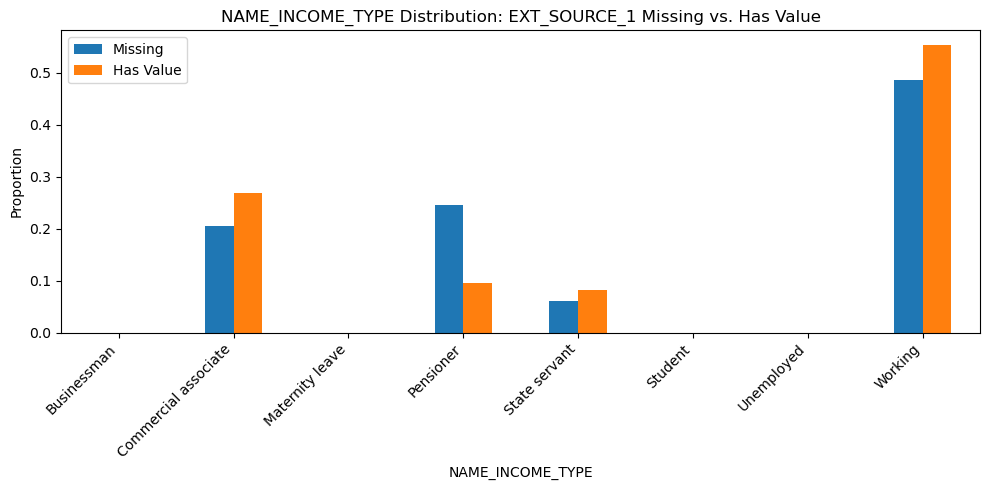

In [18]:
missing_props = df[missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True)
nonmissing_props = df[~missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True)

compare_df = pd.DataFrame({'Missing': missing_props, 'Has Value': nonmissing_props}).fillna(0)
compare_df.plot(kind='bar', figsize=(10,5))
plt.title('NAME_INCOME_TYPE Distribution: EXT_SOURCE_1 Missing vs. Has Value')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
df['EXT_SOURCE_1_missing'] = df['EXT_SOURCE_1'].isnull().astype(int)
print(df.groupby('EXT_SOURCE_1_missing')['TARGET'].mean())

EXT_SOURCE_1_missing
0    0.074955
1    0.085195
Name: TARGET, dtype: float64


#### EXT_SOURCE_1 Conclusion
> Missingness in EXT_SOURCE_1 is not random. Pensioners are disproportionately represented (~2.5x) in the missing group compared to the non-missing group, suggesting this external score may rely on data (e.g. active employment or credit history) that's less available for retirees. Checking the missingness flag directly against TARGET shows only a small difference in default rate (8.5% missing vs. 7.5% non-missing) — so while missingness is structurally non-random, it's a weak standalone predictor on its own. I'll keep the EXT_SOURCE_1_missing flag alongside imputed values, since it may still combine usefully with other features even though its direct effect is modest.

In [20]:
df['EXT_SOURCE_1'].unique()

array([0.08303697, 0.31126731,        nan, ..., 0.14557045, 0.7440264 ,
       0.73445967])

In [21]:
df['EXT_SOURCE_1'].skew()

np.float64(-0.06875505870176415)

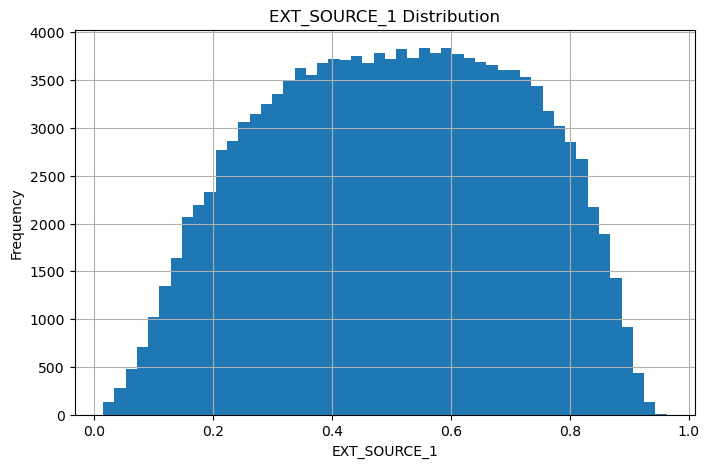

In [22]:
df['EXT_SOURCE_1'].hist(bins=50, figsize=(8,5))
plt.title('EXT_SOURCE_1 Distribution')
plt.xlabel('EXT_SOURCE_1')
plt.ylabel('Frequency')
plt.show()

#### Filling in EXT_SOURCE_1 null values
> Since EXT_SOURCE_1 is a continuous numeric column, missing values must be filled with a number rather than a categorical label like "Unknown". Its distribution is near symmetric (skew ≈ -0.069, confirmed visually), so I filled nulls with the median. The EXT_SOURCE_1_missing flag created earlier preserves the information that a value was originally missing, functioning as the numeric equivalent of an "Unknown" category.

In [23]:
df['EXT_SOURCE_1'] = df['EXT_SOURCE_1'].fillna(df['EXT_SOURCE_1'].median())

In [24]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_1_missing
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [25]:
df['EXT_SOURCE_1'].isnull().sum()

np.int64(0)

#### Successfully filled in EXT_SOURCE_1

#### Inspect 6 columns that have 41,519 values missing
> Same missing count across all 6 — likely not coincidence, suggests these are missing together in the same rows. Checking below to confirm.

In [26]:
cols_41519 = df.isnull().sum()
cols_41519 = cols_41519[cols_41519 == 41519].index.tolist()
print(cols_41519)

df[cols_41519].isnull().sum(axis=1).value_counts()

['AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']


0    265992
6     41519
Name: count, dtype: int64

In [27]:
df['bureau_missing'] = df['AMT_REQ_CREDIT_BUREAU_WEEK'].isnull().astype(int)
df.groupby('bureau_missing')['TARGET'].mean()

bureau_missing
0    0.077194
1    0.103374
Name: TARGET, dtype: float64

#### Bureau missing
> Applicants missing bureau inquiry data default at a higher rate — 10.3% vs. 7.7% when data is present.
>
> I will fill in the missing data with 0, since a missing value here most likely means no bureau record exists for that applicant, not that a real inquiry count went unrecorded
> 
> The bureau_missing flag I created already captures the risk signal from that missingness seperately, so filling with 0 keeps the actual inquiry counts logically consistent without losing signal

In [28]:
for col in cols_41519:
    df[col] = df[col].fillna(0)

## 6. Full Correlation Analysis

#### Correlation
> Find correlation between TARGET and other features

In [29]:
corr = df.corr(numeric_only=True)['TARGET'].sort_values()
print(corr)

EXT_SOURCE_3                  -0.178919
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_1                  -0.098887
DAYS_EMPLOYED                 -0.044932
FLOORSMAX_AVG                 -0.044003
                                 ...   
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, Length: 108, dtype: float64


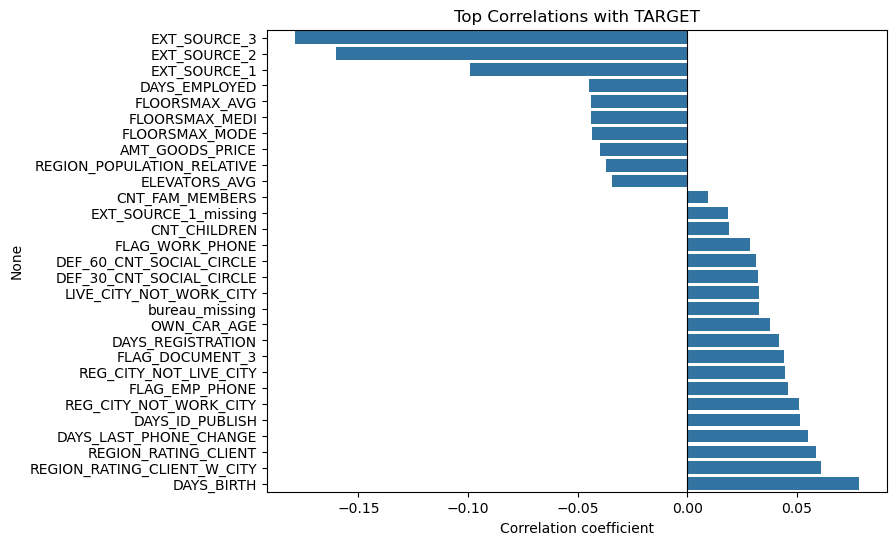

In [30]:
top_corr = pd.concat(([corr.head(10), corr.tail(20)]))
top_corr = top_corr.drop('TARGET')

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title('Top Correlations with TARGET')
plt.xlabel('Correlation coefficient')
plt.axvline(0, color='black', linewidth=0.8)

#### Correlation Summary
>
> As EXT_SOURCE_3/2/1 decrease, TARGET tends to increase (more likely to default)
>
> As EXT_SOURCE_3/2/1 increases, TARGET tends to decrease (less likely to default)
> 
> As DAYS_BIRTH increases, TARGET increases (more likely to default)
>
> As DAYS_BIRTH decreases, TARGET decreases (more likely to default)

## 7. Final Column Drops & Missingness Verification

In [31]:
df = df.drop(columns=final_drop_cols)

In [32]:
df.shape

(307511, 76)

In [33]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_1_missing,bureau_missing
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1,0


In [34]:
df.isnull().sum()

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
                             ..
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
EXT_SOURCE_1_missing          0
bureau_missing                0
Length: 76, dtype: int64

In [35]:
df.isnull().sum().value_counts()

0        64
1021      4
12        1
278       1
1292      1
96391     1
2         1
660       1
60965     1
1         1
Name: count, dtype: int64

#### Final drop columns
> After checking EXT_SOURCE_1 and deciding to keep it, I dropped the remaining 48 columns. The earlier correlation test showed almost all of them were close to 0, confirming they carried little signal for TARGET.

In [36]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing

OCCUPATION_TYPE             0.313455
EXT_SOURCE_3                0.198253
NAME_TYPE_SUITE             0.004201
DEF_30_CNT_SOCIAL_CIRCLE    0.003320
DEF_60_CNT_SOCIAL_CIRCLE    0.003320
OBS_60_CNT_SOCIAL_CIRCLE    0.003320
OBS_30_CNT_SOCIAL_CIRCLE    0.003320
EXT_SOURCE_2                0.002146
AMT_GOODS_PRICE             0.000904
AMT_ANNUITY                 0.000039
CNT_FAM_MEMBERS             0.000007
DAYS_LAST_PHONE_CHANGE      0.000003
dtype: float64

In [55]:
occ_missing_mask = df['OCCUPATION_TYPE'].isnull()
df[occ_missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True)

NAME_INCOME_TYPE
Pensioner               0.574296
Working                 0.258530
Commercial associate    0.127574
State servant           0.039288
Unemployed              0.000228
Student                 0.000052
Businessman             0.000021
Maternity leave         0.000010
Name: proportion, dtype: float64

In [56]:
df[~occ_missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True)

NAME_INCOME_TYPE
Working                 0.634019
Commercial associate    0.280978
State servant           0.084862
Student                 0.000062
Businessman             0.000038
Pensioner               0.000024
Maternity leave         0.000019
Name: proportion, dtype: float64

In [57]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

#### Filled in OCCUPATION_TYPE null values
> Filled the missing values with "Unknown". Pensioners make up 57% of the missing rows but only 0.002% of the non-missing ones, so retirement is clearly a big reason people don't have an occupation listed. But retirees aren't the whole story — about 43% of the missing rows are still Working, Commercial associate, or State servant types, so I didn't want to just label everything "Retired" and be wrong for almost half of them. "Unknown" keeps things honest without guessing.

In [59]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing

EXT_SOURCE_3                0.198253
NAME_TYPE_SUITE             0.004201
OBS_30_CNT_SOCIAL_CIRCLE    0.003320
DEF_30_CNT_SOCIAL_CIRCLE    0.003320
OBS_60_CNT_SOCIAL_CIRCLE    0.003320
DEF_60_CNT_SOCIAL_CIRCLE    0.003320
EXT_SOURCE_2                0.002146
AMT_GOODS_PRICE             0.000904
AMT_ANNUITY                 0.000039
CNT_FAM_MEMBERS             0.000007
DAYS_LAST_PHONE_CHANGE      0.000003
dtype: float64

In [60]:
ext3_missing_mask = df['EXT_SOURCE_3'].isnull()
df[ext3_missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True)

NAME_INCOME_TYPE
Working                 0.521283
Commercial associate    0.243927
Pensioner               0.181301
State servant           0.052965
Unemployed              0.000279
Businessman             0.000098
Maternity leave         0.000082
Student                 0.000066
Name: proportion, dtype: float64

In [61]:
df[~ext3_missing_mask]['NAME_INCOME_TYPE'].value_counts(normalize=True)

NAME_INCOME_TYPE
Working                 0.515093
Commercial associate    0.230164
Pensioner               0.179719
State servant           0.074931
Student                 0.000057
Unemployed              0.000020
Businessman             0.000016
Name: proportion, dtype: float64

In [62]:
df['EXT_SOURCE_3'].skew()

np.float64(-0.4093904596160267)

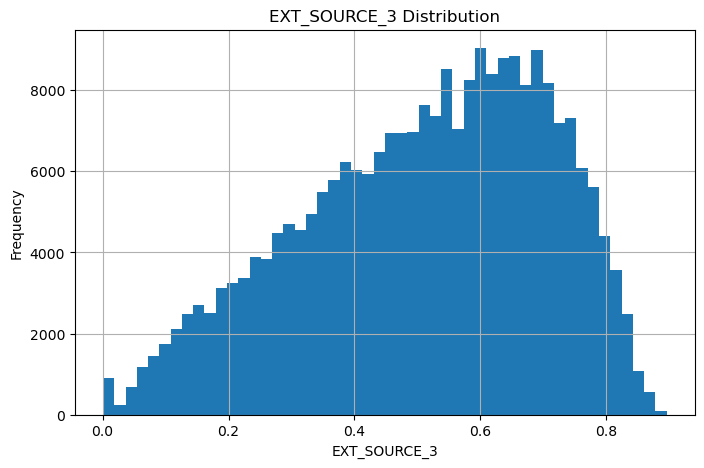

In [63]:
df['EXT_SOURCE_3'].hist(bins=50, figsize=(8,5))
plt.title('EXT_SOURCE_3 Distribution')
plt.xlabel('EXT_SOURCE_3')
plt.ylabel('Frequency')
plt.show()

In [64]:
df['EXT_SOURCE_3_missing'] = df['EXT_SOURCE_3'].isnull().astype(int)
df['EXT_SOURCE_3'] = df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_3'].median())

In [65]:
print(df.groupby('EXT_SOURCE_3_missing')['TARGET'].mean())

EXT_SOURCE_3_missing
0    0.077665
1    0.093119
Name: TARGET, dtype: float64


#### EXT_SOURCE_3 Conclusion
> Checked whether EXT_SOURCE_3's missingness follows the same pattern as EXT_SOURCE_1 and OCCUPATION_TYPE by comparing NAME_INCOME_TYPE proportions between the missing and non-missing groups — but they came out nearly identical, so missingness here doesn't seem tied to income type or employment status like it did for the other two.
Since the reason for missingness isn't clear, I filled the nulls with the median instead of a targeted value. The distribution is left-skewed (skew ≈ -0.41), with a long tail of low values pulling toward 0 — confirmed by the histogram — so median is a better representative fill than mean, which would be dragged down by that tail.
>
> Checking EXT_SOURCE_3_missing directly against TARGET shows a real gap — 9.3% default rate when missing vs. 7.8% when present. So even though the cause isn't income-type related, missingness itself still carries some predictive signal. I'll keep the EXT_SOURCE_3_missing flag alongside the median-filled values, same reasoning as EXT_SOURCE_1.

In [69]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing

NAME_TYPE_SUITE             0.004201
OBS_30_CNT_SOCIAL_CIRCLE    0.003320
DEF_30_CNT_SOCIAL_CIRCLE    0.003320
OBS_60_CNT_SOCIAL_CIRCLE    0.003320
DEF_60_CNT_SOCIAL_CIRCLE    0.003320
EXT_SOURCE_2                0.002146
AMT_GOODS_PRICE             0.000904
AMT_ANNUITY                 0.000039
CNT_FAM_MEMBERS             0.000007
DAYS_LAST_PHONE_CHANGE      0.000003
dtype: float64

In [ ]:
social_cols = ['OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 
               'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']
# Confirm they all have the same missing count
df[social_cols].isnull().sum()

OBS_30_CNT_SOCIAL_CIRCLE    1021
DEF_30_CNT_SOCIAL_CIRCLE    1021
OBS_60_CNT_SOCIAL_CIRCLE    1021
DEF_60_CNT_SOCIAL_CIRCLE    1021
dtype: int64

In [71]:
# If they're the same rows, this should equal the missing count for one column
df[social_cols].isnull().all(axis=1).sum()

np.int64(1021)

In [72]:
df['social_circle_missing'] = df['OBS_30_CNT_SOCIAL_CIRCLE'].isnull().astype(int)

In [76]:
for col in social_cols:
    df[col] = df[col].fillna(0)

In [77]:
df.groupby('social_circle_missing')['TARGET'].mean()

social_circle_missing
0    0.08088
1    0.03526
Name: TARGET, dtype: float64

#### Social Circle Missing Conclusion
> Checked whether missing social circle data (OBS_30/DEF_30/OBS_60/DEF_60_CNT_SOCIAL_CIRCLE, all missing in the same ~1,021 rows) relates to default risk. Unlike bureau and EXT_SOURCE_1/3, where missing data meant a higher default rate, here it's flipped — people missing social circle data default less often (3.5%) than people who have it (8.1%), more than a 2x gap. I'll keep the social_circle_missing flag since this is a real signal, just in the opposite direction from what I've seen with the other columns. I'll fill the four underlying columns with 0, same reasoning as bureau — no social circle data likely means no observed circle to report on, not that a real count went unrecorded.

In [79]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing

NAME_TYPE_SUITE           0.004201
EXT_SOURCE_2              0.002146
AMT_GOODS_PRICE           0.000904
AMT_ANNUITY               0.000039
CNT_FAM_MEMBERS           0.000007
DAYS_LAST_PHONE_CHANGE    0.000003
dtype: float64

In [83]:
df['NAME_TYPE_SUITE'].unique()

array(['Unaccompanied', 'Family', 'Spouse, partner', 'Children',
       'Other_A', nan, 'Other_B', 'Group of people'], dtype=object)

In [84]:
df['NAME_TYPE_SUITE'].value_counts()

NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

In [85]:
df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].fillna('Unaccompanied')

In [86]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
missing

EXT_SOURCE_2              0.002146
AMT_GOODS_PRICE           0.000904
AMT_ANNUITY               0.000039
CNT_FAM_MEMBERS           0.000007
DAYS_LAST_PHONE_CHANGE    0.000003
dtype: float64

In [87]:
trivial_numeric_cols = ['EXT_SOURCE_2', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 
                         'CNT_FAM_MEMBERS', 'DAYS_LAST_PHONE_CHANGE']

for col in trivial_numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [88]:
df.isnull().sum().sum()

np.int64(0)

In [92]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_1_missing,bureau_missing,EXT_SOURCE_3_missing,social_circle_missing
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307511.000000,3.075110e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.487841,5.383163e+05,0.020868,-16036.995067,63815.045904,...,0.005538,0.006055,0.029723,0.231293,0.229631,1.643447,0.563811,0.135016,0.198253,0.003320
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.461065,3.692890e+05,0.013831,4363.988632,141275.766519,...,0.078014,0.103037,0.190728,0.856810,0.744059,1.855821,0.495912,0.341742,0.398684,0.057526
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000,1.000000,1.000000,1.000000,1.000000


In [93]:
df['DAYS_EMPLOYED'].value_counts()

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
           ...  
-13961         1
-11827         1
-10176         1
-9459          1
-8694          1
Name: count, Length: 12574, dtype: int64

In [94]:
df[df['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts(normalize=True)

NAME_INCOME_TYPE
Pensioner     0.999603
Unemployed    0.000397
Name: proportion, dtype: float64

In [95]:
df['DAYS_EMPLOYED_anomaly'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

In [96]:
df.groupby('DAYS_EMPLOYED_anomaly')['TARGET'].mean()

DAYS_EMPLOYED_anomaly
0    0.086600
1    0.053996
Name: TARGET, dtype: float64

#### After filling in the missing values
> After filling missing values, I ran .describe() on the full numeric set and noticed DAYS_EMPLOYED's max is 365,243 — roughly 1,000 years, which is impossible. Checking .value_counts() confirms this exact value appears 55,000+ times, meaning it's a placeholder for "not currently employed" rather than real data. I'll create a flag and treat these as missing before imputing.